In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer/")
import utils.utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df.reset_index(inplace=True)
label_df["index"] = label_df.index.astype(np.int32)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered)
print(label_df_filtered["label"].value_counts())

             index        label_id  depth  label  dom_label   5mer  drach
0                0    NM_000084:34      7      0        0.0  GCAGA  False
1                1    NM_000084:36      7      0        0.0  AGAGA  False
2                2    NM_000084:38      7      0        0.0  AGAAT  False
3                3    NM_000084:39      7      0        0.0  GAATG  False
4                4    NM_000084:43      7      0        0.0  GCAGC  False
...            ...             ...    ...    ...        ...    ...    ...
30960221  30960221  NR_176252:1213     37      0        0.0  TTACT  False
30960222  30960222  NR_176252:1218     36      0        0.0  TTAAA  False
30960223  30960223  NR_176252:1219     36      0        0.0  TAAAA  False
30960224  30960224  NR_176252:1220     36      0        0.0  AAAAT  False
30960225  30960225  NR_176252:1221     36      0        0.0  AAATG  False

[18499997 rows x 7 columns]
label
0    18399879
1      100118
Name: count, dtype: int64


In [3]:
label_alt = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/label/GLORIPUB.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_alt = label_alt[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_alt.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_alt.reset_index(inplace=True)
label_alt["index"] = label_alt.index.astype(np.int32)
label_alt_filtered = label_alt[((label_alt["dom_label"] > 0.0) & (label_alt["label"] == 1)) | (label_alt["label"] == 0)]
print(label_alt_filtered)
print(label_alt_filtered["label"].value_counts())

             index        label_id  depth  label  dom_label   5mer  drach
362            362    NM_000986:32   8001      0        0.0  GGAGC  False
364            364    NM_000986:45   8014      0        0.0  TGAAG  False
365            365    NM_000986:46   8015      0        0.0  GAAGG  False
367            367    NM_000986:60   8027      0        0.0  GCAGT  False
369            369    NM_000986:73   8033      0        0.0  GTACA  False
...            ...             ...    ...    ...        ...    ...    ...
30959767  30959767  NR_182068:1325      6      0        0.0  ATAAA  False
30959768  30959768  NR_182068:1326      6      0        0.0  TAAAG  False
30959769  30959769  NR_182068:1327      6      0        0.0  AAAGC  False
30959770  30959770  NR_182068:1334      6      0        0.0  GTACC  False
30959771  30959771  NR_182068:1337      6      0        0.0  CCATG  False

[17310037 rows x 7 columns]
label
0    17226003
1       84034
Name: count, dtype: int64


In [4]:
dorado_alt = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl")
dorado_alt = dorado_alt[dorado_alt["dorado_count"] >= 20]
dorado_alt = dorado_alt[["pred_dorado", "dorado_count", "label_id"]]
print(dorado_alt)

          pred_dorado  dorado_count       label_id
413            0.5250            40    NM_000016:0
414            0.0164            61    NM_000016:2
415            0.0822            73    NM_000016:5
417            0.0250           160   NM_000016:21
418            0.0710           155   NM_000016:24
...               ...           ...            ...
59475965       0.1795            39  NR_184306:326
59475966       0.0488            41  NR_184306:330
59475967       0.0000            40  NR_184306:331
59475968       0.0000            41  NR_184306:333
59475969       0.0000            24  NR_184306:334

[15457254 rows x 3 columns]


In [5]:
logsum_alt = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-v1B-20240726-102006-21-356000-token_normalise_dwell_bq_npz_allmotif_numid-ON0090-allmotif/pileup.npz"
with np.load(logsum_alt, allow_pickle=True) as data:
    logsum_alt = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_alt = logsum_alt[logsum_alt["count_dom"] >= 20]
print(logsum_alt)

          label_id     p_sum  logsum_1_p_pos       dom  count_all  count_dom  \
1831          1832  0.135246             0.0  0.000000         20         20   
1836          1837  0.314370             0.0  0.000000         21         21   
1837          1838  1.168962             0.0  0.047619         21         21   
1840          1841  1.222882             0.0  0.050000         21         20   
1841          1842  0.889351             0.0  0.000000         21         20   
...            ...       ...             ...       ...        ...        ...   
30894445  30960573  0.043163             0.0  0.000000         50         50   
30894446  30960574  0.346144             0.0  0.000000         50         50   
30894447  30960575  0.698572             0.0  0.000000         50         48   
30894448  30960576  2.805038             0.0  0.040000         51         50   
30894449  30960577  2.364753             0.0  0.020833         51         48   

          count_pos  
1831             

In [6]:
m6anet_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/m6anet/out/data.site_proba.csv")
m6anet_df["id"] = m6anet_df["transcript_id"].str.split(".").str[0]
m6anet_df["id"] = m6anet_df["id"] + ":" + m6anet_df["transcript_position"].astype(str)
m6anet_df.rename(columns = {"id": "label_id", "probability_modified": "pred_m6anet", "mod_ratio": "dom_m6anet"}, inplace = True)
m6anet_df = m6anet_df[["label_id", "pred_m6anet", "dom_m6anet"]]
print(m6anet_df)

             label_id  pred_m6anet  dom_m6anet
0        NM_000017:44     0.944216    0.851852
1       NM_000017:158     0.718827    0.458333
2       NM_000017:168     0.112776    0.056075
3       NM_000017:189     0.127073    0.032258
4       NM_000017:199     0.910825    0.764706
...               ...          ...         ...
474111   NR_184306:93     0.980678    0.794872
474112  NR_184306:174     0.481733    0.142857
474113  NR_184306:231     0.158632    0.075000
474114  NR_184306:305     0.175728    0.069767
474115  NR_184306:312     0.037475    0.022222

[474116 rows x 3 columns]


In [7]:
logsum_alt = logsum_alt.fillna(0)
logsum_alt["pm6a"] =  -(2-logsum_alt["dom"])*logsum_alt["logsum_1_p_pos"]/logsum_alt["count_all"] + ((1-logsum_alt["dom"])*np.log10(np.clip(1-logsum_alt["dom"],1e-30,1)) + logsum_alt["dom"] * np.log10(np.clip(logsum_alt["dom"],1e-30,1)))*(logsum_alt["count_pos"]/logsum_alt["count_all"])
label_glori = label_df[["label_id", "dom_label"]].copy()
label_glori.rename({"dom_label": "dom_alt"}, axis=1, inplace=True)
logsum_alt.rename({"label_id":"label_index"}, axis=1, inplace=True)
logsum_alt = logsum_alt.merge(label_alt_filtered, left_on="label_index", how="inner", right_index=True)
logsum_alt = logsum_alt.merge(label_glori, on="label_id", how="inner")
logsum_alt["ambiguous"] = ((logsum_alt["dom_alt"] > 0) & (logsum_alt["dom_label"] == 0))|(logsum_alt["dom_alt"] == 0) & (logsum_alt["dom_label"] > 0)
print(logsum_alt)

         label_index     p_sum  logsum_1_p_pos       dom  count_all  \
0               1832  0.135246             0.0  0.000000         20   
1               1837  0.314370             0.0  0.000000         21   
2               1838  1.168962             0.0  0.047619         21   
3               1841  1.222882             0.0  0.050000         21   
4               1842  0.889351             0.0  0.000000         21   
...              ...       ...             ...       ...        ...   
8919270     30956422  3.585689             0.0  0.083333         28   
8919271     30956423  1.709157             0.0  0.000000         29   
8919272     30956424  1.863426             0.0  0.000000         27   
8919273     30956425  0.684205             0.0  0.000000         27   
8919274     30956426  1.776638             0.0  0.000000         25   

         count_dom  count_pos  pm6a     index           label_id  depth  \
0               20          0   0.0      1832  NM_001005476:3808    117 

In [9]:
dorado_alt = dorado_alt.merge(label_alt_filtered, on="label_id", how="inner")
dorado_alt = dorado_alt.merge(label_glori, on="label_id", how="inner")
dorado_alt["ambiguous"] = ((dorado_alt["dom_alt"] > 0) & (dorado_alt["dom_label"] == 0))|(dorado_alt["dom_alt"] == 0) & (dorado_alt["dom_label"] > 0)
print(dorado_alt)

         pred_dorado  dorado_count        label_id     index  depth  label  \
0             0.0822            73     NM_000016:5  12670138     76      0   
1             0.0250           160    NM_000016:21  12670139    168      0   
2             0.0710           155    NM_000016:24  12670140    182      0   
3             0.0460           174    NM_000016:29  12670141    199      0   
4             0.0266           188    NM_000016:30  12670142    200      0   
...              ...           ...             ...       ...    ...    ...   
9748425       0.0000            47  NR_182669:3964  19933967     55      0   
9748426       0.0000            53  NR_182669:3965  19933968     55      0   
9748427       0.1458            48  NR_182669:3966  19933969     55      0   
9748428       0.0000            50  NR_182669:3968  19933970     55      0   
9748429       0.0204            49  NR_182669:3969  19933971     55      0   

         dom_label   5mer  drach   dom_alt  ambiguous  
0      

In [10]:
m6anet_alt = m6anet_df.merge(label_alt_filtered, on="label_id", how="inner")
m6anet_alt = m6anet_alt.merge(label_glori, on="label_id", how="inner")
m6anet_alt["ambiguous"] = ((m6anet_alt["dom_alt"] > 0) & (m6anet_alt["dom_label"] == 0))|(m6anet_alt["dom_alt"] == 0) & (m6anet_alt["dom_label"] > 0)
print(m6anet_alt)

              label_id  pred_m6anet  dom_m6anet    index  depth  label  \
0         NM_000017:44     0.944216    0.851852  7285525     74      0   
1        NM_000017:158     0.718827    0.458333  7285538    114      0   
2        NM_000017:168     0.112776    0.056075  7285540    114      0   
3        NM_000017:189     0.127073    0.032258  7285546    116      0   
4        NM_000017:199     0.910825    0.764706  7285548    117      0   
...                ...          ...         ...      ...    ...    ...   
259536  NR_182661:2152     0.045493    0.015707  2163526    261      0   
259537  NR_182661:2174     0.079866    0.025381  2163530    262      0   
259538  NR_182661:2230     0.121530    0.038251  2163544    260      0   
259539  NR_182661:2234     0.606691    0.269231  2163546    260      0   
259540  NR_182661:2247     0.856056    0.486631  2163551    260      0   

        dom_label   5mer  drach   dom_alt  ambiguous  
0             0.0  GGACT   True  0.038345       True  
1

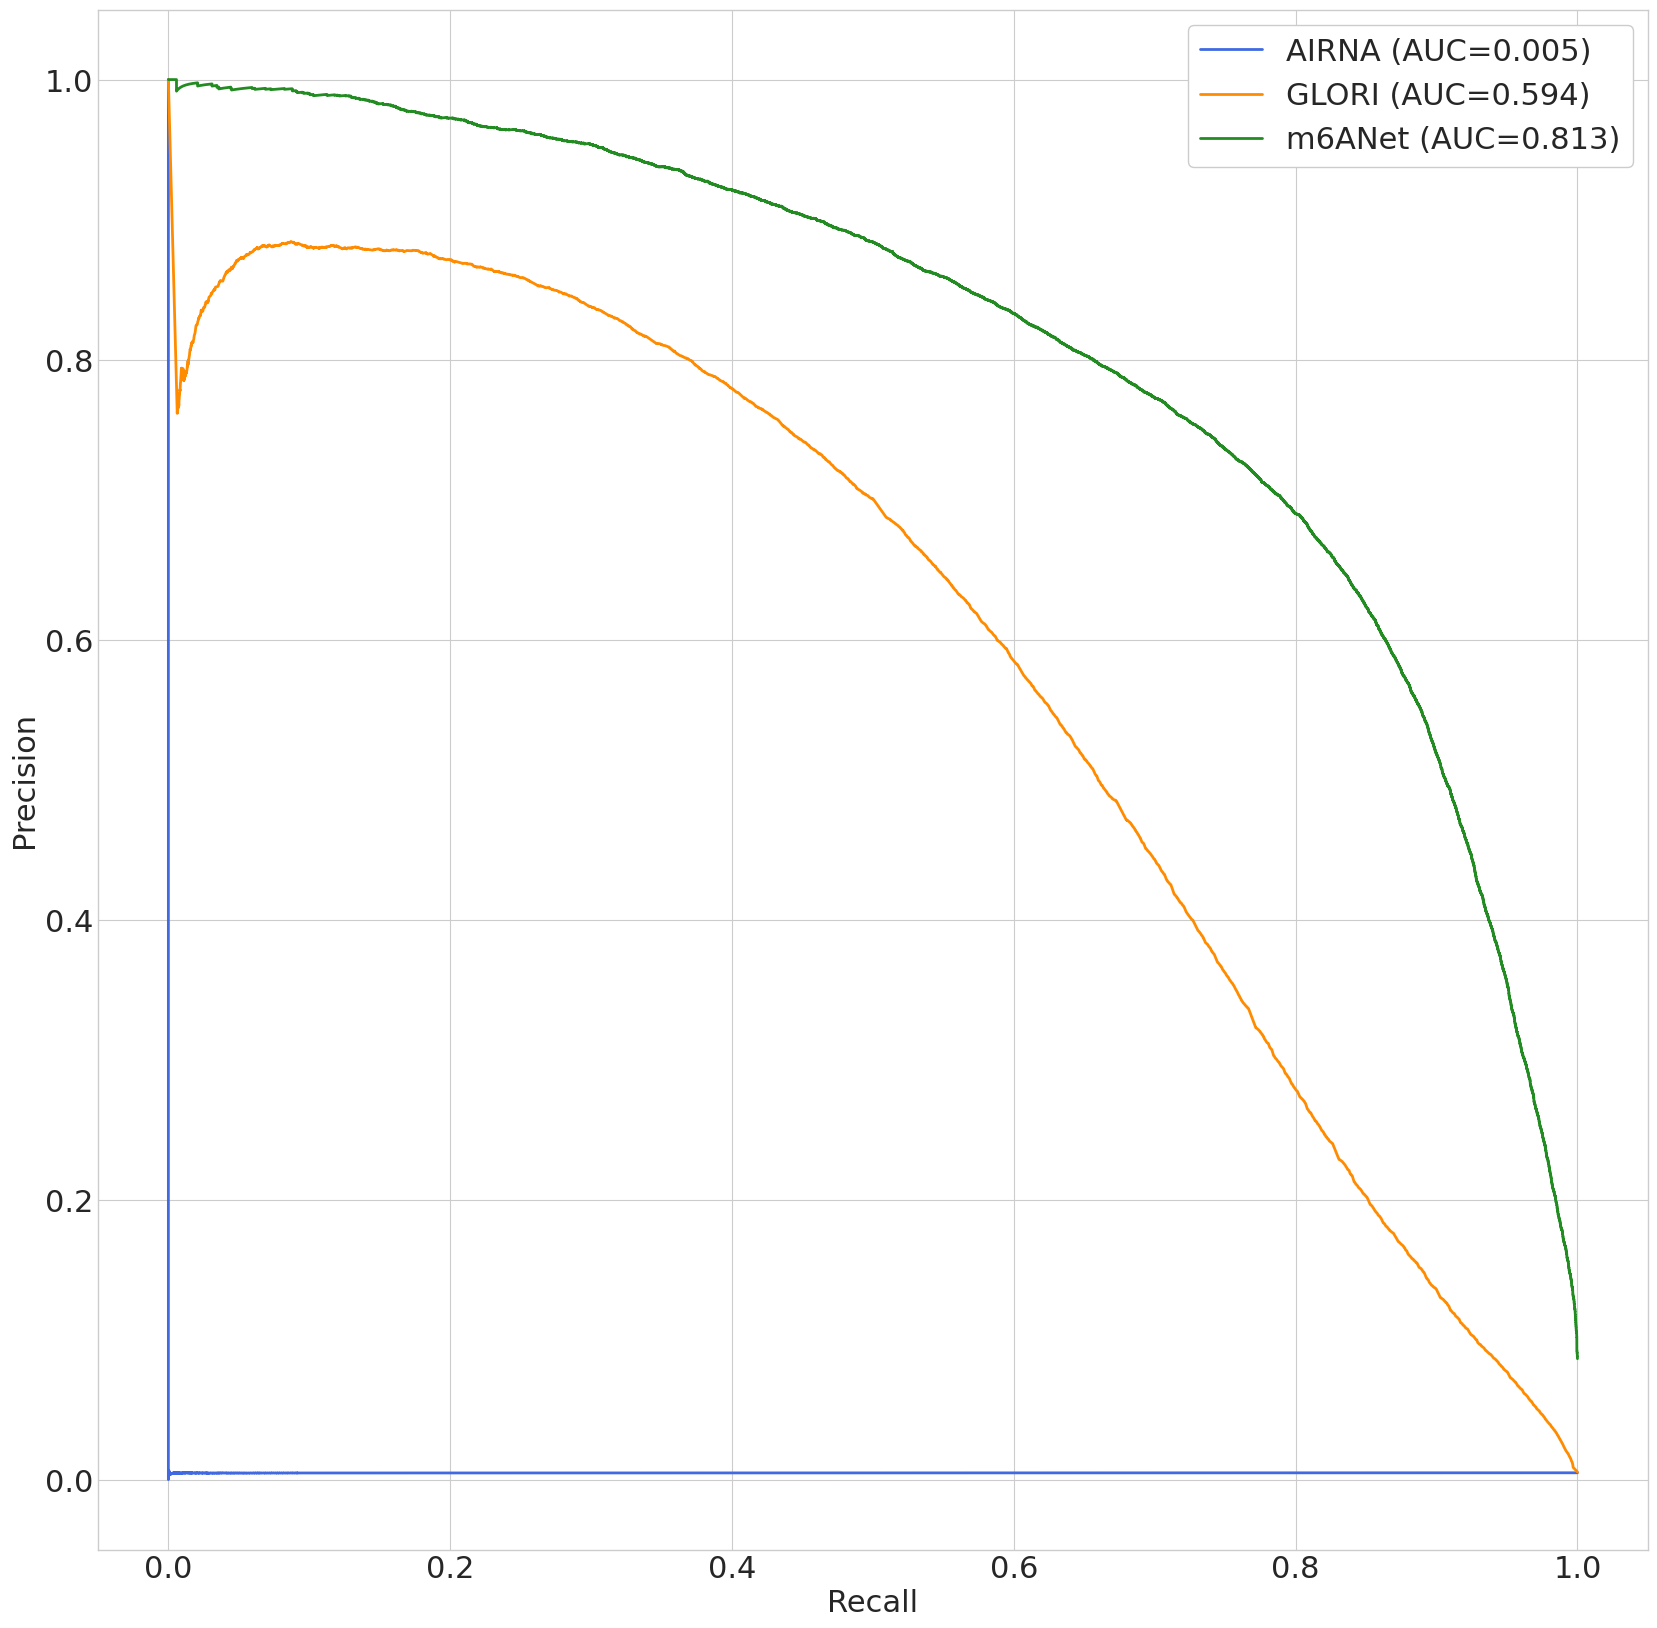

In [11]:
## Plot PR
from sklearn.metrics import precision_recall_curve, auc

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = logsum_alt[(logsum_alt["count_dom"] >= 20) & (logsum_alt["label"] >= 0) & ~(logsum_alt["ambiguous"] )]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC={auc_score:.3f})", color="royalblue")

selected_df = dorado_alt[(dorado_alt["dorado_count"] >= 20) & (dorado_alt["label"] >= 0) & ~(dorado_alt["ambiguous"] )]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"GLORI (AUC={auc_score:.3f})", color="darkorange")

selected_df = m6anet_alt[(m6anet_alt["label"] >= 0) & ~(m6anet_alt["ambiguous"] )]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC={auc_score:.3f})", color="forestgreen")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.show()

In [ ]:
print()